<a href="https://colab.research.google.com/github/akshayjoseph1999-maker/Akshay/blob/main/A_Comparative_Analysis_of_Entanglement_Dynamics_and_Local%E2%80%93Global_State_Diagnostics_Across_Five_Quantum_Computational_Paradigms(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Common Framework


In [1]:
import numpy as np

I2 = np.eye(2, dtype=complex)

X = np.array([[0, 1],
              [1, 0]], dtype=complex)

Y = np.array([[0, -1j],
              [1j, 0]], dtype=complex)

Z = np.array([[1, 0],
              [0, -1]], dtype=complex)

H = np.array([[1, 1],
              [1, -1]], dtype=complex) / np.sqrt(2)

In [2]:
def zero_product_density(n):
    dim = 2**n
    psi = np.zeros(dim, dtype=complex)
    psi[0] = 1.0
    rho = np.outer(psi, psi.conj())
    return rho


def plus_product_density(n):
    psi_plus = np.array([1, 1], dtype=complex) / np.sqrt(2)
    psi = np.array([1.0 + 0j])

    for _ in range(n):
        psi = np.kron(psi, psi_plus)

    rho = np.outer(psi, psi.conj())
    return rho


def ghz_density(n):
    dim = 2**n
    psi = np.zeros(dim, dtype=complex)
    psi[0] = 1 / np.sqrt(2)
    psi[-1] = 1 / np.sqrt(2)
    rho = np.outer(psi, psi.conj())
    return rho, psi


def maximally_mixed_density(n):
    dim = 2**n
    rho = np.eye(dim, dtype=complex) / dim
    return rho

In [3]:
def clean_density_matrix(rho, tol=1e-12):
    rho = np.asarray(rho, dtype=complex)
    rho = (rho + rho.conj().T) / 2
    trace = np.trace(rho)

    if abs(trace) < tol:
        raise ValueError("Density matrix has zero trace.")

    rho = rho / trace
    rho[np.abs(rho) < tol] = 0.0
    return rho


def validate_density_matrix(rho, tol=1e-10):
    rho = np.asarray(rho, dtype=complex)

    is_square = (rho.ndim == 2 and
                 rho.shape[0] == rho.shape[1])

    if not is_square:
        raise ValueError("Density matrix must be square.")

    hermiticity_error = np.linalg.norm(
        rho - rho.conj().T
    )

    trace_value = np.trace(rho)

    eigenvalues = np.linalg.eigvalsh(
        (rho + rho.conj().T) / 2
    )

    min_eigenvalue = np.min(eigenvalues)

    checks = {
        "trace": float(np.real(trace_value)),
        "hermiticity_error": float(hermiticity_error),
        "min_eigenvalue": float(min_eigenvalue),
        "trace_ok": abs(trace_value - 1.0) < tol,
        "hermitian_ok": hermiticity_error < tol,
        "positive_ok": min_eigenvalue >= -tol
    }

    return checks

In [4]:
def von_neumann_entropy(rho, tol=1e-12):
    rho = clean_density_matrix(rho, tol=tol)
    eigenvalues = np.linalg.eigvalsh(rho)
    eigenvalues = eigenvalues[eigenvalues > tol]
    entropy = -np.sum(eigenvalues * np.log2(eigenvalues))
    return float(np.real(entropy))


def purity(rho):
    rho = clean_density_matrix(rho)
    value = np.trace(rho @ rho)
    return float(np.real(value))


def partial_trace(rho, keep, n_qubits):
    rho = np.asarray(rho, dtype=complex)
    keep = sorted(list(keep))
    trace_out = [q for q in range(n_qubits) if q not in keep]

    tensor = rho.reshape([2] * (2 * n_qubits))
    current_n = n_qubits

    for q in sorted(trace_out, reverse=True):
        tensor = np.trace(
            tensor,
            axis1=q,
            axis2=q + current_n
        )
        current_n -= 1

    dim_keep = 2**len(keep)
    reduced = tensor.reshape(dim_keep, dim_keep)
    return clean_density_matrix(reduced)


def average_single_qubit_entropy(rho, n_qubits):
    entropies = []

    for q in range(n_qubits):
        rho_q = partial_trace(rho, [q], n_qubits)
        Sq = von_neumann_entropy(rho_q)
        entropies.append(Sq)

    return float(np.mean(entropies))


def half_system_entropy(rho, n_qubits):
    n_A = n_qubits // 2
    subsystem_A = list(range(n_A))
    rho_A = partial_trace(rho, subsystem_A, n_qubits)
    return von_neumann_entropy(rho_A)


def partial_transpose(rho, subsystem, n_qubits):
    rho = np.asarray(rho, dtype=complex)
    tensor = rho.reshape([2] * (2 * n_qubits))
    axes = list(range(2 * n_qubits))

    for q in subsystem:
        axes[q], axes[q + n_qubits] = (
            axes[q + n_qubits],
            axes[q]
        )

    rho_PT = np.transpose(tensor, axes=axes)
    rho_PT = rho_PT.reshape(rho.shape)
    return rho_PT


def negativity(rho, n_qubits):
    n_A = n_qubits // 2
    subsystem_A = list(range(n_A))

    rho_PT = partial_transpose(
        rho,
        subsystem_A,
        n_qubits
    )

    eigenvalues = np.linalg.eigvalsh(
        (rho_PT + rho_PT.conj().T) / 2
    )

    neg = np.sum(
        np.abs(eigenvalues[eigenvalues < 0])
    )

    return float(np.real(neg))

In [5]:
def pure_target_fidelity(rho, psi_target):
    rho = clean_density_matrix(rho)
    psi_target = np.asarray(psi_target, dtype=complex)
    psi_target = psi_target / np.linalg.norm(psi_target)

    value = np.vdot(
        psi_target,
        rho @ psi_target
    )

    return float(np.real(value))


def trajectory_fidelity(rho_noisy, rho_ideal, tol=1e-8):
    rho_noisy = clean_density_matrix(rho_noisy)
    rho_ideal = clean_density_matrix(rho_ideal)

    ideal_purity = purity(rho_ideal)

    if abs(ideal_purity - 1.0) > tol:
        raise ValueError(
            "trajectory_fidelity assumes a pure ideal state."
        )

    value = np.trace(rho_ideal @ rho_noisy)
    return float(np.real(value))

In [6]:
def evaluate_metrics(rho,
                     n_qubits,
                     rho_ideal=None,
                     psi_target=None):

    results = {}

    results["S_global"] = von_neumann_entropy(rho)

    results["purity"] = purity(rho)

    results["S1"] = average_single_qubit_entropy(
        rho,
        n_qubits
    )

    results["S_half"] = half_system_entropy(
        rho,
        n_qubits
    )

    results["negativity"] = negativity(
        rho,
        n_qubits
    )

    if rho_ideal is not None:
        results["F_track"] = trajectory_fidelity(
            rho_noisy=rho,
            rho_ideal=rho_ideal
        )
    else:
        results["F_track"] = None

    if psi_target is not None:
        results["F_target"] = pure_target_fidelity(
            rho=rho,
            psi_target=psi_target
        )
    else:
        results["F_target"] = None

    return results

In [7]:
def embed_single_qubit_operator(operator, target, n_qubits):
    operators = [I2.copy() for _ in range(n_qubits)]
    operators[target] = operator

    full_operator = operators[0]

    for op in operators[1:]:
        full_operator = np.kron(full_operator, op)

    return full_operator


def single_qubit_depolarizing(rho, target, n_qubits, epsilon):

    if epsilon == 0:
        return rho.copy()

    Xq = embed_single_qubit_operator(X, target, n_qubits)
    Yq = embed_single_qubit_operator(Y, target, n_qubits)
    Zq = embed_single_qubit_operator(Z, target, n_qubits)

    noisy_rho = (
        (1 - epsilon) * rho
        + (epsilon / 3) * (
            Xq @ rho @ Xq.conj().T
            + Yq @ rho @ Yq.conj().T
            + Zq @ rho @ Zq.conj().T
        )
    )

    return clean_density_matrix(noisy_rho)


def two_qubit_depolarizing(rho, q1, q2, n_qubits, epsilon):

    if epsilon == 0:
        return rho.copy()

    paulis = [I2, X, Y, Z]

    noisy_rho = (1 - epsilon) * rho.copy()

    for a, P1 in enumerate(paulis):

        for b, P2 in enumerate(paulis):

            if a == 0 and b == 0:
                continue

            operators = [I2.copy() for _ in range(n_qubits)]
            operators[q1] = P1
            operators[q2] = P2

            P_full = operators[0]

            for op in operators[1:]:
                P_full = np.kron(P_full, op)

            noisy_rho += (epsilon / 15) * (
                P_full @ rho @ P_full.conj().T
            )

    return clean_density_matrix(noisy_rho)

In [8]:
def embed_single_qubit_operator(operator, target, n_qubits):
    operators = [I2.copy() for _ in range(n_qubits)]
    operators[target] = operator

    full_operator = operators[0]

    for op in operators[1:]:
        full_operator = np.kron(full_operator, op)

    return full_operator

def apply_local_unitary_density(rho, U, target, n):
    tensor = rho.reshape([2] * (2 * n))

    tensor = np.tensordot(U, tensor, axes=(1, target))
    tensor = np.moveaxis(tensor, 0, target)

    tensor = np.tensordot(U.conj(), tensor, axes=(1, n + target))
    tensor = np.moveaxis(tensor, 0, n + target)

    return tensor.reshape(rho.shape)


def apply_all_qubit_depolarizing(rho, n, epsilon):
    if epsilon == 0.0:
        return rho.copy()

    for q in range(n):
        rho_X = apply_local_unitary_density(rho, X, q, n)
        rho_Y = apply_local_unitary_density(rho, Y, q, n)
        rho_Z = apply_local_unitary_density(rho, Z, q, n)

        rho = (
            (1.0 - epsilon) * rho
            + (epsilon / 3.0) * (rho_X + rho_Y + rho_Z)
        )

    return rho


def single_qubit_depolarizing(rho, target, n_qubits, epsilon):

    if epsilon == 0:
        return rho.copy()

    Xq = embed_single_qubit_operator(X, target, n_qubits)
    Yq = embed_single_qubit_operator(Y, target, n_qubits)
    Zq = embed_single_qubit_operator(Z, target, n_qubits)

    noisy_rho = (
        (1 - epsilon) * rho
        + (epsilon / 3) * (
            Xq @ rho @ Xq.conj().T
            + Yq @ rho @ Yq.conj().T
            + Zq @ rho @ Zq.conj().T
        )
    )

    return clean_density_matrix(noisy_rho)


def two_qubit_depolarizing(rho, q1, q2, n_qubits, epsilon):

    if epsilon == 0:
        return rho.copy()

    paulis = [I2, X, Y, Z]

    noisy_rho = (1 - epsilon) * rho.copy()

    for a, P1 in enumerate(paulis):

        for b, P2 in enumerate(paulis):

            if a == 0 and b == 0:
                continue

            operators = [I2.copy() for _ in range(n_qubits)]
            operators[q1] = P1
            operators[q2] = P2

            P_full = operators[0]

            for op in operators[1:]:
                P_full = np.kron(P_full, op)

            noisy_rho += (epsilon / 15) * (
                P_full @ rho @ P_full.conj().T
            )

    return clean_density_matrix(noisy_rho)

Validation.

In [9]:
n_test = 4

rho_product = zero_product_density(n_test)

rho_ghz, psi_ghz = ghz_density(n_test)

rho_mixed = maximally_mixed_density(n_test)

test_states = {
    "Product |0000>": rho_product,
    "GHZ": rho_ghz,
    "Maximally mixed": rho_mixed
}

In [10]:
for name, rho in test_states.items():

    print("\n" + "=" * 65)
    print(name)
    print("=" * 65)

    checks = validate_density_matrix(rho)

    print("Physicality checks:")
    print(checks)

    metrics = evaluate_metrics(
        rho=rho,
        n_qubits=n_test
    )

    print("\nMetrics:")

    for key, value in metrics.items():
        print(f"{key:12s}: {value}")


Product |0000>
Physicality checks:
{'trace': 1.0, 'hermiticity_error': 0.0, 'min_eigenvalue': 0.0, 'trace_ok': np.True_, 'hermitian_ok': np.True_, 'positive_ok': np.True_}

Metrics:
S_global    : -0.0
purity      : 1.0
S1          : 0.0
S_half      : -0.0
negativity  : 0.0
F_track     : None
F_target    : None

GHZ
Physicality checks:
{'trace': 0.9999999999999998, 'hermiticity_error': 0.0, 'min_eigenvalue': 0.0, 'trace_ok': np.True_, 'hermitian_ok': np.True_, 'positive_ok': np.True_}

Metrics:
S_global    : -0.0
purity      : 1.0
S1          : 1.0
S_half      : 1.0
negativity  : 0.4999999999999999
F_track     : None
F_target    : None

Maximally mixed
Physicality checks:
{'trace': 1.0, 'hermiticity_error': 0.0, 'min_eigenvalue': 0.0625, 'trace_ok': np.True_, 'hermitian_ok': np.True_, 'positive_ok': np.True_}

Metrics:
S_global    : 4.0
purity      : 0.0625
S1          : 1.0
S_half      : 2.0
negativity  : 0.0
F_track     : None
F_target    : None


In [11]:
tol = 1e-9


m_product = evaluate_metrics(
    rho_product,
    n_test
)

assert abs(m_product["S_global"] - 0.0) < tol
assert abs(m_product["purity"] - 1.0) < tol
assert abs(m_product["S1"] - 0.0) < tol
assert abs(m_product["S_half"] - 0.0) < tol
assert abs(m_product["negativity"] - 0.0) < tol


m_ghz = evaluate_metrics(
    rho_ghz,
    n_test
)

assert abs(m_ghz["S_global"] - 0.0) < tol
assert abs(m_ghz["purity"] - 1.0) < tol
assert abs(m_ghz["S1"] - 1.0) < tol
assert abs(m_ghz["S_half"] - 1.0) < tol
assert abs(m_ghz["negativity"] - 0.5) < tol


m_mixed = evaluate_metrics(
    rho_mixed,
    n_test
)

assert abs(m_mixed["S_global"] - n_test) < tol
assert abs(m_mixed["purity"] - 1/(2**n_test)) < tol
assert abs(m_mixed["S1"] - 1.0) < tol
assert abs(m_mixed["S_half"] - n_test//2) < tol
assert abs(m_mixed["negativity"] - 0.0) < tol


print("ALL COMMON METRIC VALIDATION TESTS PASSED")

ALL COMMON METRIC VALIDATION TESTS PASSED


In [12]:
rho_test = zero_product_density(2)

rho_no_noise = single_qubit_depolarizing(
    rho=rho_test,
    target=0,
    n_qubits=2,
    epsilon=0.0
)

difference = np.linalg.norm(rho_no_noise - rho_test)

print("Zero-noise single-qubit channel error =", difference)

assert difference < 1e-12


rho_noisy_test = single_qubit_depolarizing(
    rho=rho_test,
    target=0,
    n_qubits=2,
    epsilon=0.1
)

noise_checks = validate_density_matrix(rho_noisy_test)

print("Noisy-state physicality =", noise_checks)

assert noise_checks["trace_ok"]
assert noise_checks["hermitian_ok"]
assert noise_checks["positive_ok"]


print("ALL NOISE-CHANNEL VALIDATION TESTS PASSED")

Zero-noise single-qubit channel error = 0.0
Noisy-state physicality = {'trace': 1.0, 'hermiticity_error': 0.0, 'min_eigenvalue': 0.0, 'trace_ok': np.True_, 'hermitian_ok': np.True_, 'positive_ok': np.True_}
ALL NOISE-CHANNEL VALIDATION TESTS PASSED


QHWT



QHWT STRUCTURAL AND ZERO-NOISE VALIDATION
 n  Kernel factors H1  Permutation factors H2  Total factors  Unitarity error  Zero-noise F_track
 2                  2                       1              3     7.057214e-16                 1.0
 3                  3                       2              5     1.119768e-15                 1.0
 4                  4                       3              7     1.757844e-15                 1.0
 5                  5                       4              9     2.561779e-15                 1.0
 6                  6                       5             11     3.678839e-15                 1.0
 7                  7                       6             13     5.296305e-15                 1.0
 8                  8                       7             15     7.526592e-15                 1.0

QHWT MAIN RESULT TABLE
 n  F_track  S1_ideal  S1_noisy  Negativity_ideal  Negativity_noisy  Purity_ideal  Purity_noisy
 2 0.951813  0.600876  0.641220          0.353553    

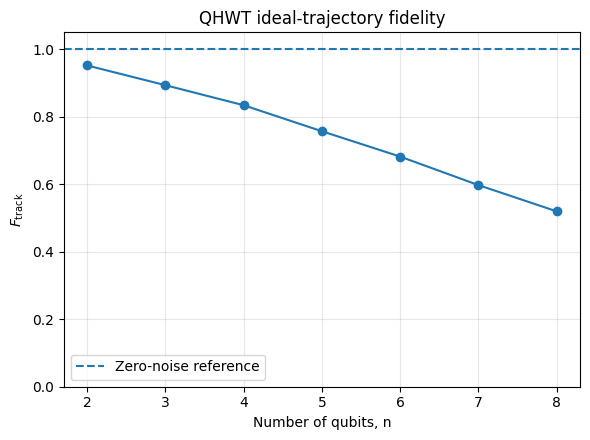

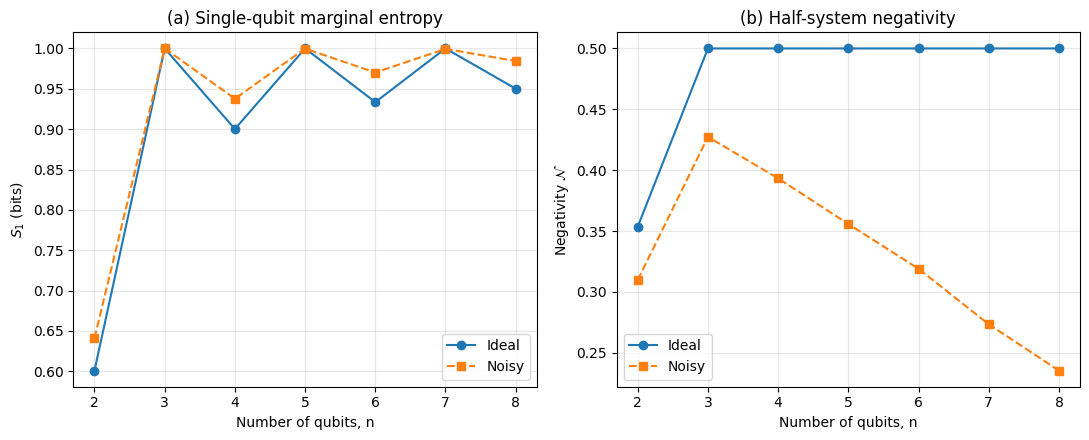


QHWT NUMERICAL SUMMARY FOR THE RESULTS SECTION
 n  F_track  S1_noisy  Negativity_noisy  Purity_noisy
 2 0.951813  0.641220          0.309721      0.906998
 3 0.893391  1.000000          0.427324      0.800341
 4 0.834046  0.937699          0.393255      0.699606
 5 0.757003  0.999826          0.355755      0.579213
 6 0.681851  0.970146          0.318973      0.473444
 7 0.597502  0.999452          0.273428      0.367817
 8 0.519765  0.984382          0.235320      0.282568

QHWT n=7 NOISE-SENSITIVITY CHECK
 epsilon  F_track       S1  Negativity   Purity
    0.00 1.000000 1.000000    0.500000 1.000000
    0.01 0.771522 0.999791    0.370640 0.599225
    0.02 0.597502 0.999452    0.273428 0.367817
    0.03 0.464903 0.999185    0.200443 0.232831
    0.04 0.363778 0.999035    0.145682 0.152951


In [13]:




import pandas as pd
import matplotlib.pyplot as plt


EPSILON_QHWT_1Q = 0.02
EPSILON_QHWT_2Q = 0.02
QHWT_N_VALUES = range(2, 9)


def direct_sum(A, B):
    rows = A.shape[0] + B.shape[0]
    cols = A.shape[1] + B.shape[1]
    result = np.zeros((rows, cols), dtype=complex)
    result[:A.shape[0], :A.shape[1]] = A
    result[A.shape[0]:, A.shape[1]:] = B
    return result


def perfect_shuffle(dimension):
    k = int(round(np.log2(dimension)))
    if 2**k != dimension:
        raise ValueError("Perfect-shuffle dimension must be a power of 2.")
    P = np.zeros((dimension, dimension), dtype=complex)
    for column in range(dimension):
        bits = [(column >> (k - 1 - j)) & 1 for j in range(k)]
        shuffled_bits = [bits[-1]] + bits[:-1]
        row = sum(shuffled_bits[j] << (k - 1 - j) for j in range(k))
        P[row, column] = 1.0
    return P


def build_qhwt_factors(n):
    N = 2**n
    permutation_factors = []
    kernel_factors = []

    for k in range(n, 1, -1):
        active_dimension = 2**k
        Pi = perfect_shuffle(active_dimension)
        if active_dimension < N:
            Pi_full = direct_sum(Pi, np.eye(N - active_dimension))
        else:
            Pi_full = Pi
        permutation_factors.append((Pi_full, k))

    for k in range(1, n + 1):
        active_dimension = 2**k
        active_kernel = np.kron(np.eye(active_dimension // 2), H)
        if active_dimension < N:
            kernel_full = direct_sum(active_kernel,
                                     np.eye(N - active_dimension))
        else:
            kernel_full = active_kernel
        kernel_factors.append((kernel_full, k))

    return permutation_factors, kernel_factors


def build_qhwt_unitary(n):
    permutation_factors, kernel_factors = build_qhwt_factors(n)
    U = np.eye(2**n, dtype=complex)
    for P, _ in permutation_factors:
        U = P @ U
    for K, _ in kernel_factors:
        U = K @ U
    return U


def run_qhwt(rho_initial, n, epsilon_1q, epsilon_2q):
    permutation_factors, kernel_factors = build_qhwt_factors(n)
    rho_ideal = rho_initial.copy()
    rho_noisy = rho_initial.copy()

    for P, k in permutation_factors:
        rho_ideal = P @ rho_ideal @ P.conj().T
        rho_noisy = P @ rho_noisy @ P.conj().T
        for q in range(n - 2, n - k - 1, -1):
            rho_noisy = two_qubit_depolarizing(
                rho=rho_noisy,
                q1=q,
                q2=q + 1,
                n_qubits=n,
                epsilon=epsilon_2q
            )

    for K, _ in kernel_factors:
        rho_ideal = K @ rho_ideal @ K.conj().T
        rho_noisy = K @ rho_noisy @ K.conj().T
        rho_noisy = single_qubit_depolarizing(
            rho=rho_noisy,
            target=n - 1,
            n_qubits=n,
            epsilon=epsilon_1q
        )

    return rho_ideal, rho_noisy


validation_rows = []

for n in QHWT_N_VALUES:
    U = build_qhwt_unitary(n)
    permutation_factors, kernel_factors = build_qhwt_factors(n)
    unitary_error = np.linalg.norm(U.conj().T @ U - np.eye(2**n))
    rho_input, _ = ghz_density(n)
    rho_zero_ideal, rho_zero_noisy = run_qhwt(
        rho_initial=rho_input,
        n=n,
        epsilon_1q=0.0,
        epsilon_2q=0.0
    )
    F_zero = trajectory_fidelity(rho_zero_noisy, rho_zero_ideal)
    assert len(kernel_factors) == n
    assert len(permutation_factors) == n - 1
    assert len(kernel_factors) + len(permutation_factors) == 2*n - 1
    assert unitary_error < 1e-10
    assert abs(F_zero - 1.0) < 1e-10
    validation_rows.append({
        "n": n,
        "Kernel factors H1": len(kernel_factors),
        "Permutation factors H2": len(permutation_factors),
        "Total factors": len(kernel_factors) + len(permutation_factors),
        "Unitarity error": unitary_error,
        "Zero-noise F_track": F_zero
    })

qhwt_validation = pd.DataFrame(validation_rows)

print("\nQHWT STRUCTURAL AND ZERO-NOISE VALIDATION")
print(qhwt_validation.to_string(index=False))


result_rows = []

for n in QHWT_N_VALUES:
    rho_input, _ = ghz_density(n)
    rho_ideal, rho_noisy = run_qhwt(
        rho_initial=rho_input,
        n=n,
        epsilon_1q=EPSILON_QHWT_1Q,
        epsilon_2q=EPSILON_QHWT_2Q
    )

    ideal_checks = validate_density_matrix(rho_ideal)
    noisy_checks = validate_density_matrix(rho_noisy)
    assert ideal_checks["trace_ok"] and ideal_checks["hermitian_ok"]
    assert ideal_checks["positive_ok"]
    assert noisy_checks["trace_ok"] and noisy_checks["hermitian_ok"]
    assert noisy_checks["positive_ok"]

    ideal_metrics = evaluate_metrics(
        rho=rho_ideal,
        n_qubits=n
    )

    noisy_metrics = evaluate_metrics(
        rho=rho_noisy,
        n_qubits=n,
        rho_ideal=rho_ideal
    )

    result_rows.append({
        "n": n,
        "F_track": noisy_metrics["F_track"],
        "S1_ideal": ideal_metrics["S1"],
        "S1_noisy": noisy_metrics["S1"],
        "Negativity_ideal": ideal_metrics["negativity"],
        "Negativity_noisy": noisy_metrics["negativity"],
        "Purity_ideal": ideal_metrics["purity"],
        "Purity_noisy": noisy_metrics["purity"]
    })

qhwt_results = pd.DataFrame(result_rows)

print("\nQHWT MAIN RESULT TABLE")
print(qhwt_results.round(6).to_string(index=False))


plt.figure(figsize=(6, 4.5))
plt.plot(qhwt_results["n"], qhwt_results["F_track"], marker="o")
plt.axhline(1.0, linestyle="--", label="Zero-noise reference")
plt.xlabel("Number of qubits, n")
plt.ylabel(r"$F_{\mathrm{track}}$")
plt.title("QHWT ideal-trajectory fidelity")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].plot(qhwt_results["n"], qhwt_results["S1_ideal"],
           marker="o", label="Ideal")
ax[0].plot(qhwt_results["n"], qhwt_results["S1_noisy"],
           marker="s", linestyle="--", label="Noisy")
ax[0].set_xlabel("Number of qubits, n")
ax[0].set_ylabel(r"$S_1$ (bits)")
ax[0].set_title("(a) Single-qubit marginal entropy")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(qhwt_results["n"], qhwt_results["Negativity_ideal"],
           marker="o", label="Ideal")
ax[1].plot(qhwt_results["n"], qhwt_results["Negativity_noisy"],
           marker="s", linestyle="--", label="Noisy")
ax[1].set_xlabel("Number of qubits, n")
ax[1].set_ylabel(r"Negativity $\mathcal{N}$")
ax[1].set_title("(b) Half-system negativity")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


qhwt_purity_table = qhwt_results[
    ["n", "F_track", "S1_noisy", "Negativity_noisy", "Purity_noisy"]
].copy()

print("\nQHWT NUMERICAL SUMMARY FOR THE RESULTS SECTION")
print(qhwt_purity_table.round(6).to_string(index=False))


sensitivity_rows = []
for eps in [0.00, 0.01, 0.02, 0.03, 0.04]:
    rho_input, _ = ghz_density(7)
    rho_ideal, rho_noisy = run_qhwt(rho_input, 7, eps, eps)
    metrics = evaluate_metrics(rho_noisy, 7, rho_ideal=rho_ideal)
    sensitivity_rows.append({
        "epsilon": eps,
        "F_track": metrics["F_track"],
        "S1": metrics["S1"],
        "Negativity": metrics["negativity"],
        "Purity": metrics["purity"]
    })

qhwt_sensitivity = pd.DataFrame(sensitivity_rows)

print("\nQHWT n=7 NOISE-SENSITIVITY CHECK")
print(qhwt_sensitivity.round(6).to_string(index=False))

QFT



QFT CIRCUIT AND ZERO-NOISE VALIDATION
 n  ||U_circuit-U_exact||  ||UdagU-I||  Zero-noise F_track
 2           5.955586e-16 8.888759e-16                 1.0
 3           2.492642e-15 1.573765e-15                 1.0
 4           7.794288e-15 2.373971e-15                 1.0
 5           2.374000e-14 2.496052e-15                 1.0
 6           6.483209e-14 1.193171e-14                 1.0
 7           1.853242e-13 2.053507e-14                 1.0
 8           5.277858e-13 2.924375e-14                 1.0

QFT MAIN RESULT TABLE
 n  F_track  S1_ideal  S1_noisy  Negativity_ideal  Negativity_noisy  Purity_ideal  Purity_noisy
 2 0.842473  0.600876  0.748894          0.353553          0.221352           1.0      0.718356
 3 0.726532  0.499845  0.731201          0.378558          0.193534           1.0      0.541065
 4 0.577049  0.397915  0.744129          0.211502          0.053575           1.0      0.351365
 5 0.458355  0.323888  0.755626          0.216114          0.036215           1.0 

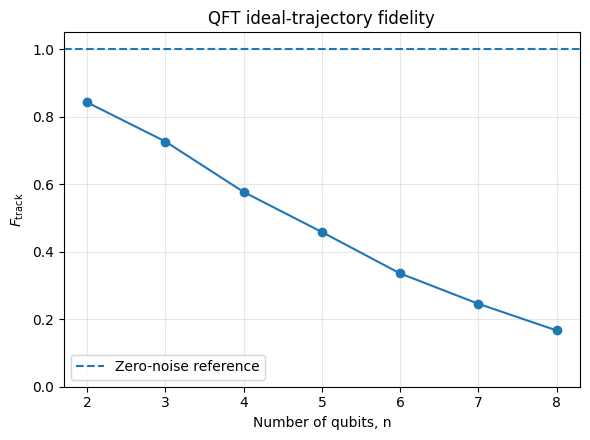

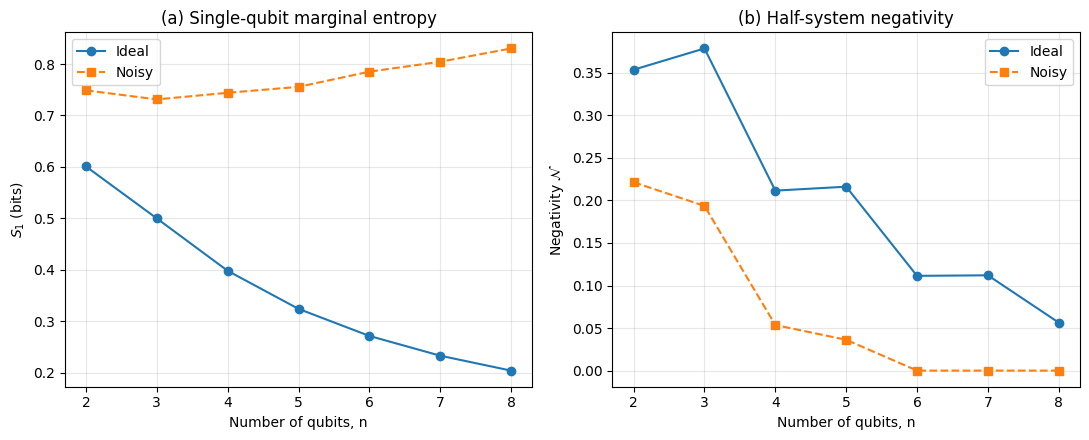


QFT NUMERICAL SUMMARY FOR THE RESULTS SECTION
 n  F_track  S1_noisy  Negativity_noisy  Purity_noisy
 2 0.842473  0.748894          0.221352      0.718356
 3 0.726532  0.731201          0.193534      0.541065
 4 0.577049  0.744129          0.053575      0.351365
 5 0.458355  0.755626          0.036215      0.229486
 6 0.335697  0.785127          0.000000      0.130992
 7 0.245819  0.804450          0.000000      0.075750
 8 0.166825  0.830327          0.000000      0.039164


In [14]:




import pandas as pd
import matplotlib.pyplot as plt


EPSILON_QFT_1Q = 0.05
EPSILON_QFT_2Q = 0.05
QFT_N_VALUES = range(2, 9)


def controlled_phase_matrix(theta, q1, q2, n):
    dimension = 2**n
    diagonal = np.ones(dimension, dtype=complex)

    for basis_index in range(dimension):
        bit_q1 = (basis_index >> (n - 1 - q1)) & 1
        bit_q2 = (basis_index >> (n - 1 - q2)) & 1

        if bit_q1 == 1 and bit_q2 == 1:
            diagonal[basis_index] = np.exp(1j * theta)

    return np.diag(diagonal)


def swap_matrix(q1, q2, n):
    dimension = 2**n
    S = np.zeros((dimension, dimension), dtype=complex)

    for column in range(dimension):
        bits = [(column >> (n - 1 - j)) & 1 for j in range(n)]
        bits[q1], bits[q2] = bits[q2], bits[q1]
        row = sum(bits[j] << (n - 1 - j) for j in range(n))
        S[row, column] = 1.0

    return S


def analytical_qft_matrix(n):
    dimension = 2**n
    x = np.arange(dimension)
    xy = np.outer(x, x)
    U_exact = np.exp(2j * np.pi * xy / dimension) / np.sqrt(dimension)
    return U_exact


def build_qft_unitary(n):
    U = np.eye(2**n, dtype=complex)

    for target in range(n):
        H_target = embed_single_qubit_operator(H, target, n)
        U = H_target @ U

        for control in range(target + 1, n):
            theta = np.pi / (2**(control - target))
            CP = controlled_phase_matrix(theta, control, target, n)
            U = CP @ U

    for q1 in range(n // 2):
        q2 = n - 1 - q1
        SW = swap_matrix(q1, q2, n)
        U = SW @ U

    return U


def run_qft(rho_initial, n, epsilon_1q, epsilon_2q):
    rho_ideal = rho_initial.copy()
    rho_noisy = rho_initial.copy()

    for target in range(n):
        H_target = embed_single_qubit_operator(H, target, n)

        rho_ideal = H_target @ rho_ideal @ H_target.conj().T
        rho_noisy = H_target @ rho_noisy @ H_target.conj().T

        rho_noisy = single_qubit_depolarizing(
            rho=rho_noisy,
            target=target,
            n_qubits=n,
            epsilon=epsilon_1q
        )

        for control in range(target + 1, n):
            theta = np.pi / (2**(control - target))
            CP = controlled_phase_matrix(theta, control, target, n)

            rho_ideal = CP @ rho_ideal @ CP.conj().T
            rho_noisy = CP @ rho_noisy @ CP.conj().T

            rho_noisy = two_qubit_depolarizing(
                rho=rho_noisy,
                q1=control,
                q2=target,
                n_qubits=n,
                epsilon=epsilon_2q
            )

    for q1 in range(n // 2):
        q2 = n - 1 - q1
        SW = swap_matrix(q1, q2, n)

        rho_ideal = SW @ rho_ideal @ SW.conj().T
        rho_noisy = SW @ rho_noisy @ SW.conj().T

        rho_noisy = two_qubit_depolarizing(
            rho=rho_noisy,
            q1=q1,
            q2=q2,
            n_qubits=n,
            epsilon=epsilon_2q
        )

    return rho_ideal, rho_noisy


qft_validation_rows = []

for n in QFT_N_VALUES:
    U_circuit = build_qft_unitary(n)
    U_exact = analytical_qft_matrix(n)
    qft_matrix_error = np.linalg.norm(U_circuit - U_exact)
    unitarity_error = np.linalg.norm(U_circuit.conj().T @
                                     U_circuit -
                                     np.eye(2**n))

    rho_input, _ = ghz_density(n)

    rho_zero_ideal, rho_zero_noisy = run_qft(
        rho_initial=rho_input,
        n=n,
        epsilon_1q=0.0,
        epsilon_2q=0.0
    )

    F_zero = trajectory_fidelity(
        rho_noisy=rho_zero_noisy,
        rho_ideal=rho_zero_ideal
    )

    assert qft_matrix_error < 1e-10
    assert unitarity_error < 1e-10
    assert abs(F_zero - 1.0) < 1e-10

    qft_validation_rows.append({
        "n": n,
        "||U_circuit-U_exact||": qft_matrix_error,
        "||UdagU-I||": unitarity_error,
        "Zero-noise F_track": F_zero
    })


qft_validation = pd.DataFrame(qft_validation_rows)

print("\nQFT CIRCUIT AND ZERO-NOISE VALIDATION")
print(qft_validation.to_string(index=False))


qft_result_rows = []

for n in QFT_N_VALUES:
    rho_input, _ = ghz_density(n)

    rho_ideal, rho_noisy = run_qft(
        rho_initial=rho_input,
        n=n,
        epsilon_1q=EPSILON_QFT_1Q,
        epsilon_2q=EPSILON_QFT_2Q
    )

    ideal_checks = validate_density_matrix(rho_ideal)
    noisy_checks = validate_density_matrix(rho_noisy)

    assert ideal_checks["trace_ok"]
    assert ideal_checks["hermitian_ok"]
    assert ideal_checks["positive_ok"]
    assert noisy_checks["trace_ok"]
    assert noisy_checks["hermitian_ok"]
    assert noisy_checks["positive_ok"]

    ideal_metrics = evaluate_metrics(
        rho=rho_ideal,
        n_qubits=n
    )

    noisy_metrics = evaluate_metrics(
        rho=rho_noisy,
        n_qubits=n,
        rho_ideal=rho_ideal
    )

    qft_result_rows.append({
        "n": n,
        "F_track": noisy_metrics["F_track"],
        "S1_ideal": ideal_metrics["S1"],
        "S1_noisy": noisy_metrics["S1"],
        "Negativity_ideal": ideal_metrics["negativity"],
        "Negativity_noisy": noisy_metrics["negativity"],
        "Purity_ideal": ideal_metrics["purity"],
        "Purity_noisy": noisy_metrics["purity"]
    })


qft_results = pd.DataFrame(qft_result_rows)

print("\nQFT MAIN RESULT TABLE")
print(qft_results.round(6).to_string(index=False))


plt.figure(figsize=(6, 4.5))
plt.plot(qft_results["n"], qft_results["F_track"], marker="o")
plt.axhline(1.0, linestyle="--", label="Zero-noise reference")
plt.xlabel("Number of qubits, n")
plt.ylabel(r"$F_{\mathrm{track}}$")
plt.title("QFT ideal-trajectory fidelity")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].plot(qft_results["n"], qft_results["S1_ideal"],
           marker="o", label="Ideal")
ax[0].plot(qft_results["n"], qft_results["S1_noisy"],
           marker="s", linestyle="--", label="Noisy")
ax[0].set_xlabel("Number of qubits, n")
ax[0].set_ylabel(r"$S_1$ (bits)")
ax[0].set_title("(a) Single-qubit marginal entropy")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(qft_results["n"], qft_results["Negativity_ideal"],
           marker="o", label="Ideal")
ax[1].plot(qft_results["n"], qft_results["Negativity_noisy"],
           marker="s", linestyle="--", label="Noisy")
ax[1].set_xlabel("Number of qubits, n")
ax[1].set_ylabel(r"Negativity $\mathcal{N}$")
ax[1].set_title("(b) Half-system negativity")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


qft_summary_table = qft_results[
    ["n", "F_track", "S1_noisy", "Negativity_noisy", "Purity_noisy"]
].copy()

print("\nQFT NUMERICAL SUMMARY FOR THE RESULTS SECTION")
print(qft_summary_table.round(6).to_string(index=False))

AQC



In [15]:




import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


J_AQC = 1.0
GAMMA_AQC = 0.02
T_AQC = 30.0
DT_AQC = 0.1
AQC_N_VALUES = range(2, 9)


def aqc_problem_energies(n, J=1.0):
    dimension = 2**n
    energies = np.zeros(dimension, dtype=float)

    for basis_index in range(dimension):
        z_values = []

        for q in range(n):
            bit = (basis_index >> (n - 1 - q)) & 1
            z_values.append(1 if bit == 0 else -1)

        energy = 0.0

        for i in range(n):
            for j in range(i + 1, n):
                energy += -(J / (n - 1)) * z_values[i] * z_values[j]

        energies[basis_index] = energy

    return energies


def apply_local_unitary_density(rho, U, target, n):
    tensor = rho.reshape([2] * (2 * n))

    tensor = np.tensordot(U, tensor, axes=(1, target))
    tensor = np.moveaxis(tensor, 0, target)

    tensor = np.tensordot(U.conj(), tensor,
                          axes=(1, n + target))
    tensor = np.moveaxis(tensor, 0, n + target)

    return tensor.reshape(rho.shape)


def apply_all_qubit_depolarizing_aqc(rho, n, epsilon):
    if epsilon == 0.0:
        return rho.copy()

    for q in range(n):
        rho_X = apply_local_unitary_density(rho, X, q, n)
        rho_Y = apply_local_unitary_density(rho, Y, q, n)
        rho_Z = apply_local_unitary_density(rho, Z, q, n)

        rho = (
            (1.0 - epsilon) * rho
            + (epsilon / 3.0) * (rho_X + rho_Y + rho_Z)
        )

    return rho

In [16]:
def aqc_unitary_step(rho, n, s, dt, problem_energies):
    angle = (1.0 - s) * dt / 2.0

    Ux_half = (
        np.cos(angle) * I2
        + 1j * np.sin(angle) * X
    )

    for q in range(n):
        rho = apply_local_unitary_density(rho, Ux_half, q, n)

    phase = np.exp(-1j * s * problem_energies * dt)

    rho = (
        phase[:, None]
        * rho
        * phase.conj()[None, :]
    )

    for q in range(n):
        rho = apply_local_unitary_density(rho, Ux_half, q, n)

    return rho


def run_aqc(n, T=T_AQC, dt=DT_AQC, J=J_AQC, gamma=GAMMA_AQC):
    steps = int(round(T / dt))
    dt = T / steps
    epsilon_step = 1.0 - np.exp(-gamma * dt)

    problem_energies = aqc_problem_energies(n, J)

    rho_initial = plus_product_density(n)
    rho_ideal = rho_initial.copy()
    rho_noisy = rho_initial.copy()

    for step in range(steps):
        s = (step + 0.5) / steps

        rho_ideal = aqc_unitary_step(
            rho_ideal, n, s, dt, problem_energies
        )

        rho_noisy = aqc_unitary_step(
            rho_noisy, n, s, dt, problem_energies
        )

        rho_noisy = apply_all_qubit_depolarizing_aqc(
            rho_noisy, n, epsilon_step
        )

    rho_ideal = clean_density_matrix(rho_ideal)
    rho_noisy = clean_density_matrix(rho_noisy)

    return rho_ideal, rho_noisy, epsilon_step


AQC IDEAL-PROTOCOL VALIDATION
 n  Ground energy  GHZ energy  Ideal F_target(GHZ)  epsilon_step
 2           -1.0        -1.0             0.999769      0.001998
 3           -1.5        -1.5             0.999764      0.001998
 4           -2.0        -2.0             0.999463      0.001998
 5           -2.5        -2.5             0.998214      0.001998
 6           -3.0        -3.0             0.996123      0.001998
 7           -3.5        -3.5             0.992243      0.001998
 8           -4.0        -4.0             0.985482      0.001998

AQC MAIN RESULT TABLE
 n  F_track  S1_ideal  S1_noisy  Negativity_ideal  Negativity_noisy  Purity_ideal  Purity_noisy
 2 0.469206  0.999985  0.999999          0.499995          0.000000           1.0      0.317139
 3 0.316053  1.000000  0.997112          0.500000          0.000000           1.0      0.175858
 4 0.215802  0.999989  0.999891          0.502644          0.019311           1.0      0.099230
 5 0.148842  0.999684  0.999802          0

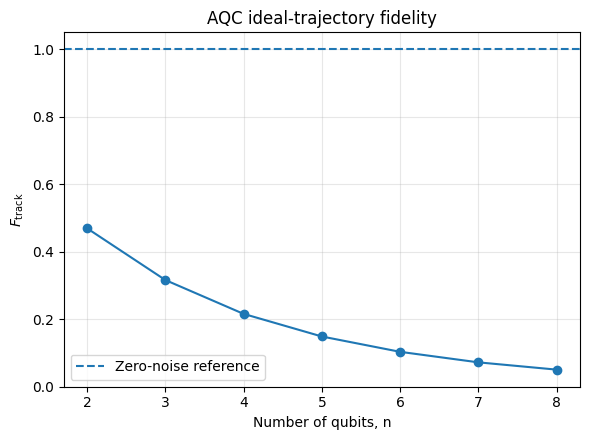

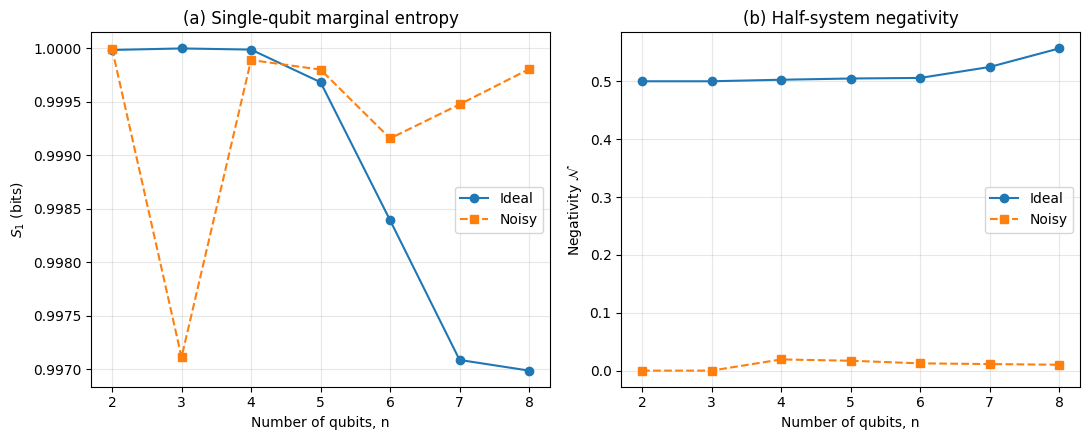


AQC NUMERICAL SUMMARY FOR THE RESULTS SECTION
 n  F_track  S1_noisy  Negativity_noisy  Purity_noisy
 2 0.469206  0.999999          0.000000      0.317139
 3 0.316053  0.997112          0.000000      0.175858
 4 0.215802  0.999891          0.019311      0.099230
 5 0.148842  0.999802          0.017063      0.056758
 6 0.103411  0.999158          0.012527      0.032793
 7 0.072234  0.999476          0.011326      0.019070
 8 0.050658  0.999806          0.010109      0.011134


In [17]:
aqc_result_rows = []
aqc_validation_rows = []


for n in AQC_N_VALUES:
    rho_ghz, psi_ghz = ghz_density(n)

    problem_energies = aqc_problem_energies(n, J_AQC)
    ground_energy = np.min(problem_energies)

    ghz_problem_energy = (
        problem_energies[0] + problem_energies[-1]
    ) / 2.0

    rho_ideal, rho_noisy, epsilon_step = run_aqc(
        n=n,
        T=T_AQC,
        dt=DT_AQC,
        J=J_AQC,
        gamma=GAMMA_AQC
    )

    ideal_checks = validate_density_matrix(rho_ideal)
    noisy_checks = validate_density_matrix(rho_noisy)

    assert ideal_checks["trace_ok"]
    assert ideal_checks["hermitian_ok"]
    assert ideal_checks["positive_ok"]

    assert noisy_checks["trace_ok"]
    assert noisy_checks["hermitian_ok"]
    assert noisy_checks["positive_ok"]

    F_target_ideal = pure_target_fidelity(
        rho=rho_ideal,
        psi_target=psi_ghz
    )

    assert abs(ghz_problem_energy - ground_energy) < 1e-10
    assert F_target_ideal > 0.98

    ideal_metrics = evaluate_metrics(
        rho=rho_ideal,
        n_qubits=n
    )

    noisy_metrics = evaluate_metrics(
        rho=rho_noisy,
        n_qubits=n,
        rho_ideal=rho_ideal
    )

    aqc_validation_rows.append({
        "n": n,
        "Ground energy": ground_energy,
        "GHZ energy": ghz_problem_energy,
        "Ideal F_target(GHZ)": F_target_ideal,
        "epsilon_step": epsilon_step
    })

    aqc_result_rows.append({
        "n": n,
        "F_track": noisy_metrics["F_track"],
        "S1_ideal": ideal_metrics["S1"],
        "S1_noisy": noisy_metrics["S1"],
        "Negativity_ideal": ideal_metrics["negativity"],
        "Negativity_noisy": noisy_metrics["negativity"],
        "Purity_ideal": ideal_metrics["purity"],
        "Purity_noisy": noisy_metrics["purity"]
    })


aqc_validation = pd.DataFrame(aqc_validation_rows)
aqc_results = pd.DataFrame(aqc_result_rows)


print("\nAQC IDEAL-PROTOCOL VALIDATION")
print(aqc_validation.round(6).to_string(index=False))


print("\nAQC MAIN RESULT TABLE")
print(aqc_results.round(6).to_string(index=False))


plt.figure(figsize=(6, 4.5))
plt.plot(aqc_results["n"], aqc_results["F_track"], marker="o")
plt.axhline(1.0, linestyle="--", label="Zero-noise reference")
plt.xlabel("Number of qubits, n")
plt.ylabel(r"$F_{\mathrm{track}}$")
plt.title("AQC ideal-trajectory fidelity")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].plot(aqc_results["n"], aqc_results["S1_ideal"],
           marker="o", label="Ideal")
ax[0].plot(aqc_results["n"], aqc_results["S1_noisy"],
           marker="s", linestyle="--", label="Noisy")
ax[0].set_xlabel("Number of qubits, n")
ax[0].set_ylabel(r"$S_1$ (bits)")
ax[0].set_title("(a) Single-qubit marginal entropy")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(aqc_results["n"], aqc_results["Negativity_ideal"],
           marker="o", label="Ideal")
ax[1].plot(aqc_results["n"], aqc_results["Negativity_noisy"],
           marker="s", linestyle="--", label="Noisy")
ax[1].set_xlabel("Number of qubits, n")
ax[1].set_ylabel(r"Negativity $\mathcal{N}$")
ax[1].set_title("(b) Half-system negativity")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


aqc_summary_table = aqc_results[
    ["n", "F_track", "S1_noisy", "Negativity_noisy", "Purity_noisy"]
].copy()


print("\nAQC NUMERICAL SUMMARY FOR THE RESULTS SECTION")
print(aqc_summary_table.round(6).to_string(index=False))

In [18]:
aqc_dt_check = []

for dt_test in [0.20, 0.10, 0.05]:
    rho_ideal_test, _, _ = run_aqc(
        n=8,
        T=T_AQC,
        dt=dt_test,
        J=J_AQC,
        gamma=0.0
    )

    _, psi_ghz_test = ghz_density(8)

    F_test = pure_target_fidelity(
        rho_ideal_test,
        psi_ghz_test
    )

    aqc_dt_check.append({
        "dt": dt_test,
        "Ideal GHZ fidelity": F_test
    })


print("\nAQC TIME-STEP CONVERGENCE CHECK")
print(pd.DataFrame(aqc_dt_check).round(8).to_string(index=False))


AQC TIME-STEP CONVERGENCE CHECK
  dt  Ideal GHZ fidelity
0.20            0.985010
0.10            0.985482
0.05            0.985598


MBQC

In [19]:




import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


EPSILON_MBQC = 0.10
MBQC_N_VALUES = range(2, 9)


def mbqc_cz_matrix(q1, q2, n_total):
    dimension = 2**n_total
    diagonal = np.ones(dimension, dtype=complex)

    for basis_index in range(dimension):
        bit_q1 = (basis_index >> (n_total - 1 - q1)) & 1
        bit_q2 = (basis_index >> (n_total - 1 - q2)) & 1

        if bit_q1 == 1 and bit_q2 == 1:
            diagonal[basis_index] = -1.0

    return np.diag(diagonal)


def build_mbqc_star_resource(n_leaves):
    n_total = n_leaves + 1
    rho_resource = plus_product_density(n_total)

    for leaf in range(1, n_total):
        CZ = mbqc_cz_matrix(0, leaf, n_total)
        rho_resource = CZ @ rho_resource @ CZ.conj().T

    return rho_resource


def mbqc_measurement_branch(rho_resource, n_leaves, outcome):
    n_total = n_leaves + 1

    ket_plus = np.array([1, 1], dtype=complex) / np.sqrt(2)
    ket_minus = np.array([1, -1], dtype=complex) / np.sqrt(2)

    ket_m = ket_plus if outcome == 0 else ket_minus
    projector_m = np.outer(ket_m, ket_m.conj())

    P_full = embed_single_qubit_operator(
        projector_m,
        target=0,
        n_qubits=n_total
    )

    rho_projected = P_full @ rho_resource @ P_full.conj().T

    probability = float(np.real(np.trace(rho_projected)))

    if probability < 1e-14:
        raise ValueError("MBQC measurement branch has zero probability.")

    rho_projected = rho_projected / probability

    rho_leaves = partial_trace(
        rho=rho_projected,
        keep=list(range(1, n_total)),
        n_qubits=n_total
    )


    if outcome == 1:
        X_leaf = embed_single_qubit_operator(
            X,
            target=0,
            n_qubits=n_leaves
        )

        rho_leaves = X_leaf @ rho_leaves @ X_leaf.conj().T


    for q in range(n_leaves):
        H_leaf = embed_single_qubit_operator(
            H,
            target=q,
            n_qubits=n_leaves
        )

        rho_leaves = H_leaf @ rho_leaves @ H_leaf.conj().T


    rho_leaves = clean_density_matrix(rho_leaves)

    return probability, rho_leaves


def mbqc_complete_output(rho_resource, n_leaves):
    output_dimension = 2**n_leaves

    rho_output = np.zeros(
        (output_dimension, output_dimension),
        dtype=complex
    )

    branch_probabilities = {}
    branch_states = {}

    for outcome in [0, 1]:
        probability, rho_branch = mbqc_measurement_branch(
            rho_resource=rho_resource,
            n_leaves=n_leaves,
            outcome=outcome
        )

        branch_probabilities[outcome] = probability
        branch_states[outcome] = rho_branch

        rho_output += probability * rho_branch


    rho_output = clean_density_matrix(rho_output)

    return rho_output, branch_probabilities, branch_states


def run_mbqc(n_leaves, epsilon_hub):
    rho_resource_ideal = build_mbqc_star_resource(n_leaves)

    n_total = n_leaves + 1

    rho_resource_noisy = single_qubit_depolarizing(
        rho=rho_resource_ideal,
        target=0,
        n_qubits=n_total,
        epsilon=epsilon_hub
    )


    rho_ideal, ideal_probs, ideal_branches = mbqc_complete_output(
        rho_resource=rho_resource_ideal,
        n_leaves=n_leaves
    )


    rho_noisy, noisy_probs, noisy_branches = mbqc_complete_output(
        rho_resource=rho_resource_noisy,
        n_leaves=n_leaves
    )


    return (
        rho_ideal,
        rho_noisy,
        ideal_probs,
        noisy_probs,
        ideal_branches,
        noisy_branches
    )


MBQC PROTOCOL AND MEASUREMENT-BRANCH VALIDATION
 n_output  n_resource  p0  p1  F_branch_0_GHZ  F_branch_1_GHZ  Ideal F_target(GHZ)  Zero-noise F_track
        2           3 0.5 0.5             1.0             1.0                  1.0                 1.0
        3           4 0.5 0.5             1.0             1.0                  1.0                 1.0
        4           5 0.5 0.5             1.0             1.0                  1.0                 1.0
        5           6 0.5 0.5             1.0             1.0                  1.0                 1.0
        6           7 0.5 0.5             1.0             1.0                  1.0                 1.0
        7           8 0.5 0.5             1.0             1.0                  1.0                 1.0
        8           9 0.5 0.5             1.0             1.0                  1.0                 1.0

MBQC MAIN RESULT TABLE
 n  F_track  S1_ideal  S1_noisy  Negativity_ideal  Negativity_noisy  Purity_ideal  Purity_noisy
 2 0.93

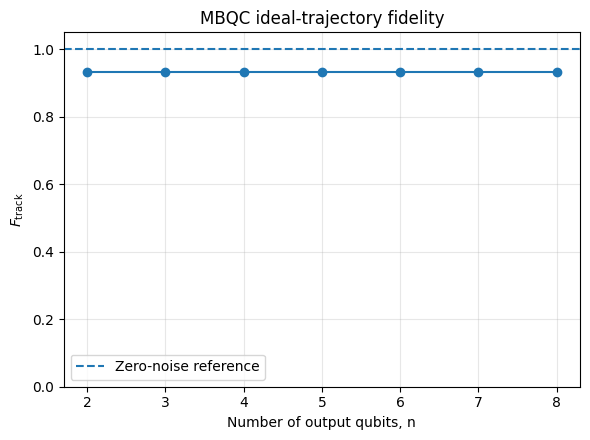

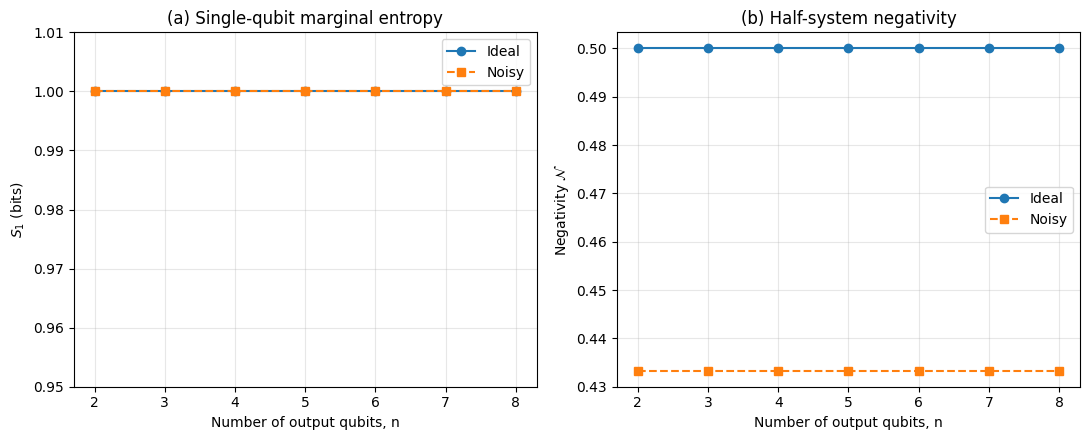


MBQC NUMERICAL SUMMARY FOR THE RESULTS SECTION
 n  F_track  S1_noisy  Negativity_noisy  Purity_noisy
 2 0.933333       1.0          0.433333      0.875556
 3 0.933333       1.0          0.433333      0.875556
 4 0.933333       1.0          0.433333      0.875556
 5 0.933333       1.0          0.433333      0.875556
 6 0.933333       1.0          0.433333      0.875556
 7 0.933333       1.0          0.433333      0.875556
 8 0.933333       1.0          0.433333      0.875556


In [20]:
mbqc_validation_rows = []
mbqc_result_rows = []


for n in MBQC_N_VALUES:
    rho_ghz, psi_ghz = ghz_density(n)

    (
        rho_ideal_zero,
        rho_noisy_zero,
        ideal_probs_zero,
        noisy_probs_zero,
        ideal_branches_zero,
        noisy_branches_zero
    ) = run_mbqc(
        n_leaves=n,
        epsilon_hub=0.0
    )


    p_sum = ideal_probs_zero[0] + ideal_probs_zero[1]

    F_branch_0 = pure_target_fidelity(
        rho=ideal_branches_zero[0],
        psi_target=psi_ghz
    )


    F_branch_1 = pure_target_fidelity(
        rho=ideal_branches_zero[1],
        psi_target=psi_ghz
    )


    F_target_ideal = pure_target_fidelity(
        rho=rho_ideal_zero,
        psi_target=psi_ghz
    )


    F_track_zero = trajectory_fidelity(
        rho_noisy=rho_noisy_zero,
        rho_ideal=rho_ideal_zero
    )


    assert abs(p_sum - 1.0) < 1e-10
    assert abs(F_branch_0 - 1.0) < 1e-10
    assert abs(F_branch_1 - 1.0) < 1e-10
    assert abs(F_target_ideal - 1.0) < 1e-10
    assert abs(F_track_zero - 1.0) < 1e-10


    mbqc_validation_rows.append({
        "n_output": n,
        "n_resource": n + 1,
        "p0": ideal_probs_zero[0],
        "p1": ideal_probs_zero[1],
        "F_branch_0_GHZ": F_branch_0,
        "F_branch_1_GHZ": F_branch_1,
        "Ideal F_target(GHZ)": F_target_ideal,
        "Zero-noise F_track": F_track_zero
    })


    (
        rho_ideal,
        rho_noisy,
        ideal_probs,
        noisy_probs,
        ideal_branches,
        noisy_branches
    ) = run_mbqc(
        n_leaves=n,
        epsilon_hub=EPSILON_MBQC
    )


    ideal_checks = validate_density_matrix(rho_ideal)
    noisy_checks = validate_density_matrix(rho_noisy)

    assert ideal_checks["trace_ok"]
    assert ideal_checks["hermitian_ok"]
    assert ideal_checks["positive_ok"]

    assert noisy_checks["trace_ok"]
    assert noisy_checks["hermitian_ok"]
    assert noisy_checks["positive_ok"]


    ideal_metrics = evaluate_metrics(
        rho=rho_ideal,
        n_qubits=n
    )


    noisy_metrics = evaluate_metrics(
        rho=rho_noisy,
        n_qubits=n,
        rho_ideal=rho_ideal
    )


    mbqc_result_rows.append({
        "n": n,
        "F_track": noisy_metrics["F_track"],
        "S1_ideal": ideal_metrics["S1"],
        "S1_noisy": noisy_metrics["S1"],
        "Negativity_ideal": ideal_metrics["negativity"],
        "Negativity_noisy": noisy_metrics["negativity"],
        "Purity_ideal": ideal_metrics["purity"],
        "Purity_noisy": noisy_metrics["purity"]
    })


mbqc_validation = pd.DataFrame(mbqc_validation_rows)
mbqc_results = pd.DataFrame(mbqc_result_rows)


print("\nMBQC PROTOCOL AND MEASUREMENT-BRANCH VALIDATION")
print(mbqc_validation.round(8).to_string(index=False))


print("\nMBQC MAIN RESULT TABLE")
print(mbqc_results.round(6).to_string(index=False))


plt.figure(figsize=(6, 4.5))
plt.plot(mbqc_results["n"], mbqc_results["F_track"], marker="o")
plt.axhline(1.0, linestyle="--", label="Zero-noise reference")
plt.xlabel("Number of output qubits, n")
plt.ylabel(r"$F_{\mathrm{track}}$")
plt.title("MBQC ideal-trajectory fidelity")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))


ax[0].plot(mbqc_results["n"], mbqc_results["S1_ideal"],
           marker="o", label="Ideal")
ax[0].plot(mbqc_results["n"], mbqc_results["S1_noisy"],
           marker="s", linestyle="--", label="Noisy")
ax[0].set_xlabel("Number of output qubits, n")
ax[0].set_ylabel(r"$S_1$ (bits)")
ax[0].set_title("(a) Single-qubit marginal entropy")
ax[0].set_ylim(0.95, 1.01)
ax[0].legend()
ax[0].grid(alpha=0.3)


ax[1].plot(mbqc_results["n"], mbqc_results["Negativity_ideal"],
           marker="o", label="Ideal")
ax[1].plot(mbqc_results["n"], mbqc_results["Negativity_noisy"],
           marker="s", linestyle="--", label="Noisy")
ax[1].set_xlabel("Number of output qubits, n")
ax[1].set_ylabel(r"Negativity $\mathcal{N}$")
ax[1].set_title("(b) Half-system negativity")
ax[1].legend()
ax[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()


mbqc_summary_table = mbqc_results[
    ["n", "F_track", "S1_noisy", "Negativity_noisy", "Purity_noisy"]
].copy()


print("\nMBQC NUMERICAL SUMMARY FOR THE RESULTS SECTION")
print(mbqc_summary_table.round(6).to_string(index=False))

QCA


In [21]:




import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


J_QCA = 1.0
H_QCA = 0.5
DT_QCA = 0.1
N_STEPS_QCA = 50
GAMMA_QCA = 0.02
QCA_N_VALUES = range(2, 9)
QCA_PLOT_N = 8


def qca_bond_sets(n):
    even_bonds = [(i, i + 1) for i in range(0, n - 1, 2)]
    odd_bonds = [(i, i + 1) for i in range(1, n - 1, 2)]
    return even_bonds, odd_bonds


def qca_zz_phase(n, bonds, J, dt):
    dimension = 2**n
    energies = np.zeros(dimension, dtype=float)

    for basis_index in range(dimension):
        energy = 0.0

        for q1, q2 in bonds:
            bit1 = (basis_index >> (n - 1 - q1)) & 1
            bit2 = (basis_index >> (n - 1 - q2)) & 1
            z1 = 1 if bit1 == 0 else -1
            z2 = 1 if bit2 == 0 else -1
            energy += -J * z1 * z2

        energies[basis_index] = energy

    phase = np.exp(-1j * energies * dt)
    return phase


def apply_diagonal_phase_density(rho, phase):
    rho = phase[:, None] * rho
    rho = rho * phase.conj()[None, :]
    return rho


def qca_unitary_step(rho, n, J, h, dt):
    even_bonds, odd_bonds = qca_bond_sets(n)

    angle = h * dt / 2.0

    Ux_half = (
        np.cos(angle) * I2
        + 1j * np.sin(angle) * X
    )

    for q in range(n):
        rho = apply_local_unitary_density(
            rho=rho,
            U=Ux_half,
            target=q,
            n=n
        )

    phase_even = qca_zz_phase(
        n=n,
        bonds=even_bonds,
        J=J,
        dt=dt
    )

    rho = apply_diagonal_phase_density(
        rho=rho,
        phase=phase_even
    )

    phase_odd = qca_zz_phase(
        n=n,
        bonds=odd_bonds,
        J=J,
        dt=dt
    )

    rho = apply_diagonal_phase_density(
        rho=rho,
        phase=phase_odd
    )

    for q in range(n):
        rho = apply_local_unitary_density(
            rho=rho,
            U=Ux_half,
            target=q,
            n=n
        )

    return rho


def run_qca(n, J=J_QCA, h=H_QCA, dt=DT_QCA, n_steps=N_STEPS_QCA,
            gamma=GAMMA_QCA):

    rho_initial, _ = ghz_density(n)
    rho_ideal = rho_initial.copy()
    rho_noisy = rho_initial.copy()

    epsilon_step = 1.0 - np.exp(-gamma * dt)

    records = []

    metrics_ideal_0 = evaluate_metrics(
        rho=rho_ideal,
        n_qubits=n
    )

    metrics_noisy_0 = evaluate_metrics(
        rho=rho_noisy,
        n_qubits=n,
        rho_ideal=rho_ideal
    )

    records.append({
        "step": 0,
        "time": 0.0,
        "F_track": metrics_noisy_0["F_track"],
        "S1_ideal": metrics_ideal_0["S1"],
        "S1_noisy": metrics_noisy_0["S1"],
        "Negativity_ideal": metrics_ideal_0["negativity"],
        "Negativity_noisy": metrics_noisy_0["negativity"],
        "Purity_ideal": metrics_ideal_0["purity"],
        "Purity_noisy": metrics_noisy_0["purity"]
    })

    for step in range(1, n_steps + 1):

        rho_ideal = qca_unitary_step(
            rho=rho_ideal,
            n=n,
            J=J,
            h=h,
            dt=dt
        )

        rho_noisy = qca_unitary_step(
            rho=rho_noisy,
            n=n,
            J=J,
            h=h,
            dt=dt
        )

        rho_noisy = apply_all_qubit_depolarizing(
            rho=rho_noisy,
            n=n,
            epsilon=epsilon_step
        )

        rho_ideal = clean_density_matrix(rho_ideal)
        rho_noisy = clean_density_matrix(rho_noisy)

        ideal_checks = validate_density_matrix(rho_ideal)
        noisy_checks = validate_density_matrix(rho_noisy)

        assert ideal_checks["trace_ok"]
        assert ideal_checks["hermitian_ok"]
        assert ideal_checks["positive_ok"]

        assert noisy_checks["trace_ok"]
        assert noisy_checks["hermitian_ok"]
        assert noisy_checks["positive_ok"]

        metrics_ideal = evaluate_metrics(
            rho=rho_ideal,
            n_qubits=n
        )

        metrics_noisy = evaluate_metrics(
            rho=rho_noisy,
            n_qubits=n,
            rho_ideal=rho_ideal
        )

        records.append({
            "step": step,
            "time": step * dt,
            "F_track": metrics_noisy["F_track"],
            "S1_ideal": metrics_ideal["S1"],
            "S1_noisy": metrics_noisy["S1"],
            "Negativity_ideal": metrics_ideal["negativity"],
            "Negativity_noisy": metrics_noisy["negativity"],
            "Purity_ideal": metrics_ideal["purity"],
            "Purity_noisy": metrics_noisy["purity"]
        })

    return pd.DataFrame(records), rho_ideal, rho_noisy, epsilon_step

In [22]:
qca_structure_rows = []

for n in QCA_N_VALUES:
    even_bonds, odd_bonds = qca_bond_sets(n)
    all_bonds = even_bonds + odd_bonds
    expected_bonds = [(i, i + 1) for i in range(n - 1)]

    assert len(set(all_bonds)) == len(all_bonds)
    assert sorted(all_bonds) == sorted(expected_bonds)

    zero_traj, zero_ideal, zero_noisy, _ = run_qca(
        n=n,
        J=J_QCA,
        h=H_QCA,
        dt=DT_QCA,
        n_steps=5,
        gamma=0.0
    )

    F_zero_final = zero_traj["F_track"].iloc[-1]

    assert abs(F_zero_final - 1.0) < 1e-10

    qca_structure_rows.append({
        "n": n,
        "Even bonds": str(even_bonds),
        "Odd bonds": str(odd_bonds),
        "Number of unique bonds": len(set(all_bonds)),
        "Expected bonds": n - 1,
        "Zero-noise F_track": F_zero_final
    })


qca_validation = pd.DataFrame(qca_structure_rows)

print("\nQCA STRUCTURAL AND ZERO-NOISE VALIDATION")
print(qca_validation.to_string(index=False))


QCA STRUCTURAL AND ZERO-NOISE VALIDATION
 n                       Even bonds                Odd bonds  Number of unique bonds  Expected bonds  Zero-noise F_track
 2                         [(0, 1)]                       []                       1               1                 1.0
 3                         [(0, 1)]                 [(1, 2)]                       2               2                 1.0
 4                 [(0, 1), (2, 3)]                 [(1, 2)]                       3               3                 1.0
 5                 [(0, 1), (2, 3)]         [(1, 2), (3, 4)]                       4               4                 1.0
 6         [(0, 1), (2, 3), (4, 5)]         [(1, 2), (3, 4)]                       5               5                 1.0
 7         [(0, 1), (2, 3), (4, 5)] [(1, 2), (3, 4), (5, 6)]                       6               6                 1.0
 8 [(0, 1), (2, 3), (4, 5), (6, 7)] [(1, 2), (3, 4), (5, 6)]                       7               7           

In [23]:
qca_all_trajectories = {}
qca_final_rows = []


for n in QCA_N_VALUES:
    trajectory, rho_ideal_final, rho_noisy_final, epsilon_step = run_qca(
        n=n,
        J=J_QCA,
        h=H_QCA,
        dt=DT_QCA,
        n_steps=N_STEPS_QCA,
        gamma=GAMMA_QCA
    )

    qca_all_trajectories[n] = trajectory

    final = trajectory.iloc[-1]

    qca_final_rows.append({
        "n": n,
        "Final time": final["time"],
        "F_track": final["F_track"],
        "S1_noisy": final["S1_noisy"],
        "Negativity_noisy": final["Negativity_noisy"],
        "Purity_noisy": final["Purity_noisy"],
        "epsilon_step": epsilon_step
    })


qca_final_table = pd.DataFrame(qca_final_rows)

print("\nQCA FINAL-TIME NUMERICAL SUMMARY")
print(qca_final_table.round(6).to_string(index=False))


QCA FINAL-TIME NUMERICAL SUMMARY
 n  Final time  F_track  S1_noisy  Negativity_noisy  Purity_noisy  epsilon_step
 2         5.0 0.842344  0.877551          0.287193      0.718137      0.001998
 3         5.0 0.771327  0.781218          0.213693      0.604252      0.001998
 4         5.0 0.693848  0.873232          0.282063      0.491688      0.001998
 5         5.0 0.630356  0.957639          0.382137      0.408153      0.001998
 6         5.0 0.573073  0.968863          0.433927      0.339684      0.001998
 7         5.0 0.521864  0.964284          0.503046      0.284061      0.001998
 8         5.0 0.475238  0.956082          0.531276      0.237983      0.001998


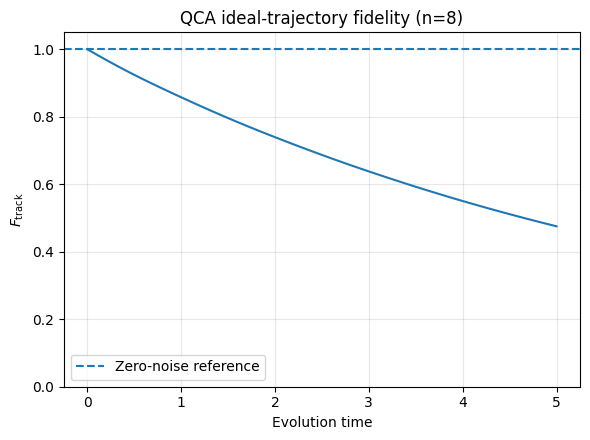

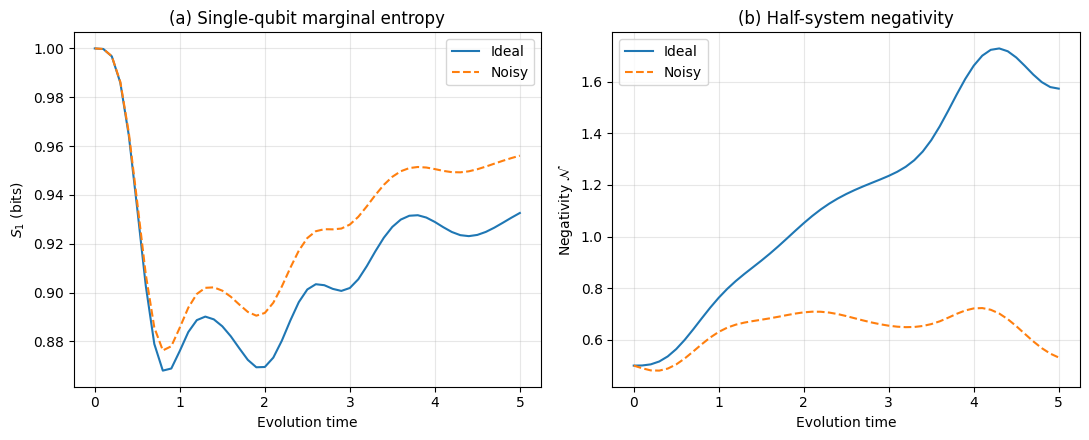

In [24]:
qca_plot = qca_all_trajectories[QCA_PLOT_N]


plt.figure(figsize=(6, 4.5))
plt.plot(qca_plot["time"], qca_plot["F_track"])
plt.axhline(1.0, linestyle="--", label="Zero-noise reference")
plt.xlabel("Evolution time")
plt.ylabel(r"$F_{\mathrm{track}}$")
plt.title(f"QCA ideal-trajectory fidelity (n={QCA_PLOT_N})")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))


ax[0].plot(qca_plot["time"], qca_plot["S1_ideal"],
           label="Ideal")
ax[0].plot(qca_plot["time"], qca_plot["S1_noisy"],
           linestyle="--", label="Noisy")
ax[0].set_xlabel("Evolution time")
ax[0].set_ylabel(r"$S_1$ (bits)")
ax[0].set_title("(a) Single-qubit marginal entropy")
ax[0].legend()
ax[0].grid(alpha=0.3)


ax[1].plot(qca_plot["time"], qca_plot["Negativity_ideal"],
           label="Ideal")
ax[1].plot(qca_plot["time"], qca_plot["Negativity_noisy"],
           linestyle="--", label="Noisy")
ax[1].set_xlabel("Evolution time")
ax[1].set_ylabel(r"Negativity $\mathcal{N}$")
ax[1].set_title("(b) Half-system negativity")
ax[1].legend()
ax[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [25]:
QCA_CONVERGENCE_N = 6
QCA_TOTAL_TIME = N_STEPS_QCA * DT_QCA


qca_convergence_states = {}


for dt_test in [0.20, 0.10, 0.05]:
    steps_test = int(round(QCA_TOTAL_TIME / dt_test))

    _, rho_ideal_test, _, _ = run_qca(
        n=QCA_CONVERGENCE_N,
        J=J_QCA,
        h=H_QCA,
        dt=dt_test,
        n_steps=steps_test,
        gamma=0.0
    )

    qca_convergence_states[dt_test] = rho_ideal_test


F_dt_020_vs_010 = trajectory_fidelity(
    rho_noisy=qca_convergence_states[0.20],
    rho_ideal=qca_convergence_states[0.10]
)


F_dt_010_vs_005 = trajectory_fidelity(
    rho_noisy=qca_convergence_states[0.10],
    rho_ideal=qca_convergence_states[0.05]
)


print("\nQCA TIME-STEP CONVERGENCE")
print("F(dt=0.20, dt=0.10) =", F_dt_020_vs_010)
print("F(dt=0.10, dt=0.05) =", F_dt_010_vs_005)


QCA TIME-STEP CONVERGENCE
F(dt=0.20, dt=0.10) = 0.9993272909800532
F(dt=0.10, dt=0.05) = 0.999957875295463
